In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/raw/campaign_data.csv")
df

,campaign_id,campaign_type,platform,region,device,age_group,season,campaign_date,budget,impressions,...,comments,leads,conversions,customer_rating,revenue,spend,profit,roi,bounce_rate,session_duration_sec
0,CMP000000,Search,Facebook,North,Desktop,55+,Summer,2023-07-22,38768.0,362738,...,614,2841,678,5.0,3378062.56,36266.59,3341795.97,9214.53,22.25,292.0
1,CMP000001,Affiliate,Facebook,East,Mobile,35-44,Festive,2025-10-22,20507.0,200613,...,437,2428,822,3.5,9658482.84,18291.93,9640190.91,52701.88,56.03,149.0
2,CMP000002,Search,Google Ads,West,Mobile,55+,Summer,2023-01-11,30433.0,309070,...,835,1890,355,3.9,1422968.99,31975.61,1390993.38,4350.17,45.96,120.0
3,CMP000003,Email,YouTube,West,Desktop,55+,Festive,2024-06-15,46373.0,1188007,...,8222,3499,1199,3.3,11784873.84,38944.35,11745929.49,30160.81,61.83,173.0
4,CMP000004,Influencer,X,West,Desktop,55+,Winter,2025-10-06,65564.0,335654,...,1460,2303,96,5.0,575532.22,64355.34,511176.88,794.30,44.34,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50495,CMP000314,Influencer,YouTube,South,Mobile,18-24,Summer,2023-03-07,134674.0,1079924,...,5803,19808,8626,5.0,70638965.85,139338.56,70499627.29,50595.92,31.03,69.0
50496,CMP011449,Influencer,X,East,Mobile,25-34,Festive,2025-12-26,117322.0,3308273,...,4007,30931,7105,4.2,35101807.77,112605.30,34989202.47,31072.43,31.40,203.0
50497,CMP030745,Search,YouTube,North,Desktop,45-54,Festive,2025-02-25,73715.0,2087526,...,10781,18675,6080,4.5,64820194.98,73798.12,64746396.86,87734.48,51.49,113.0
50498,CMP029702,Social Media,Google Ads,West,Desktop,18-24,Festive,2025-01-04,132709.0,2078916,...,4023,10001,2365,4.4,18341755.19,109267.64,18232487.55,16686.08,38.98,354.0


In [5]:
# Copy of the dataset
df_clean = df.copy()

In [8]:
# Check Missing Values
df_clean.isnull().sum()

campaign_id                0
campaign_type              0
platform                   0
region                     0
device                     0
age_group                  0
season                     0
campaign_date              0
budget                     0
impressions                0
clicks                     0
likes                      0
shares                     0
comments                   0
leads                      0
conversions                0
customer_rating         2525
revenue                    0
spend                      0
profit                     0
roi                        0
bounce_rate             2523
session_duration_sec    2523
dtype: int64

In [9]:
# Percentage Missing 
(df_clean.isnull().sum() / len(df_clean)) * 100

campaign_id             0.00000
campaign_type           0.00000
platform                0.00000
region                  0.00000
device                  0.00000
age_group               0.00000
season                  0.00000
campaign_date           0.00000
budget                  0.00000
impressions             0.00000
clicks                  0.00000
likes                   0.00000
shares                  0.00000
comments                0.00000
leads                   0.00000
conversions             0.00000
customer_rating         5.00000
revenue                 0.00000
spend                   0.00000
profit                  0.00000
roi                     0.00000
bounce_rate             4.99604
session_duration_sec    4.99604
dtype: float64

In [11]:
# Handle Numerical Missing Value
num_cols = df_clean.select_dtypes(include='number').columns

In [18]:
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

In [43]:
df_clean.isnull().sum()

campaign_type           0
platform                0
region                  0
device                  0
age_group               0
season                  0
campaign_date           0
budget                  0
impressions             0
clicks                  0
likes                   0
shares                  0
comments                0
leads                   0
conversions             0
customer_rating         0
revenue                 0
spend                   0
profit                  0
roi                     0
bounce_rate             0
session_duration_sec    0
dtype: int64

In [44]:
# Remove Duplicated Records
df_clean.duplicated().sum()

np.int64(0)

In [45]:
df_clean.drop_duplicates(inplace=True)

In [46]:
# Fix data types
df_clean.dtypes

campaign_type                   object
platform                        object
region                          object
device                          object
age_group                       object
season                          object
campaign_date           datetime64[ns]
budget                         float64
impressions                      int64
clicks                           int64
likes                            int64
shares                           int64
comments                         int64
leads                            int64
conversions                      int64
customer_rating                float64
revenue                        float64
spend                          float64
profit                         float64
roi                            float64
bounce_rate                    float64
session_duration_sec           float64
dtype: object

In [47]:
df_clean.duplicated().sum()

np.int64(0)

In [48]:
df_clean['campaign_date'] = pd.to_datetime(
    df_clean['campaign_date'],
    errors='coerce'
)

In [51]:
cat_cols = df_clean.select_dtypes(include='object').columns

In [52]:
# Categorical Columns
for col in cat_cols:
    print(col)
    print(df_clean[col].unique())

campaign_type
['Search' 'Affiliate' 'Email' 'Influencer' 'Social Media']
platform
['Facebook' 'Google Ads' 'YouTube' 'X' 'LinkedIn' 'Instagram']
region
['North' 'East' 'West' 'South' 'Central']
device
['Desktop' 'Mobile' 'Tablet']
age_group
['55+' '35-44' '45-54' '18-24' '25-34']
season
['Summer' 'Festive' 'Winter' 'Monsoon']


In [61]:
for col in cat_cols:
    print(col)
    print(df_clean[col].unique())

campaign_type
['search' 'affiliate' 'email' 'influencer' 'social media']
platform
['facebook' 'google ads' 'youtube' 'x' 'linkedin' 'instagram']
region
['north' 'east' 'west' 'south' 'central']
device
['desktop' 'mobile' 'tablet']
age_group
['55+' '35-44' '45-54' '18-24' '25-34']
season
['summer' 'festive' 'winter' 'monsoon']


In [62]:
# Standardize Text
for col in cat_cols:
    df_clean[col] = (
        df_clean[col]
        .str.strip()
        .str.lower()
    )

In [63]:
df_clean[df_clean['budget'] <= 0]
df_clean[df_clean['impressions'] < 0]
df_clean[df_clean['clicks'] < 0]
df_clean[df_clean['revenue'] < 0]

,campaign_type,platform,region,device,age_group,season,campaign_date,budget,impressions,clicks,...,comments,leads,conversions,customer_rating,revenue,spend,profit,roi,bounce_rate,session_duration_sec


<Axes: >

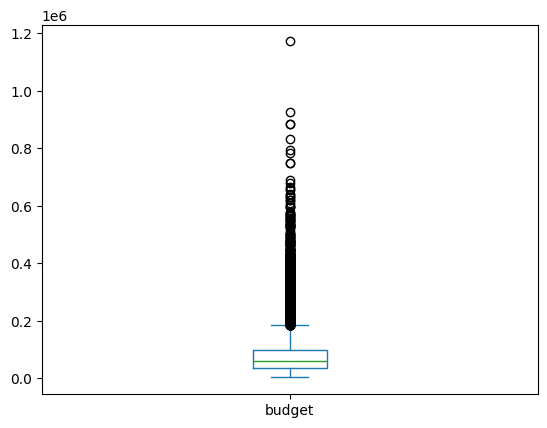

In [64]:
df_clean['budget'].plot(kind='box')

In [65]:
df_clean[['roi', 'profit', 'revenue', 'spend']].corr()

,roi,profit,revenue,spend
roi,1.000000,0.727401,0.726679,-0.001021
profit,0.727401,1.000000,0.999997,0.350953
revenue,0.726679,0.999997,1.000000,0.353415
spend,-0.001021,0.350953,0.353415,1.000000


In [67]:
cat_cols = df_clean.select_dtypes(include='object').columns

In [68]:
for col in cat_cols:
    mode_value = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_value)

In [70]:
from pathlib import Path

# Define the file path
output_path = Path("../data/cleaned/campaign_data_cleaned.csv")

# Create the directories if they don't exist yet
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save the DataFrame
df_clean.to_csv(output_path, index=False)